Using device: cuda
Using parameters: input_dim=60, seq_len=4
Model loaded from britd_model.pth (Size: 1.22 MB)
Input dimension: 60

Performance Metrics:
Mean Reconstruction Error (MSE): 0.014252
Std of Reconstruction Errors: 0.118690
Anomaly Threshold: 0.251633
Anomaly Rate: 0.57%
Inference Time: 5.07 seconds
Model Size: 1.22 MB


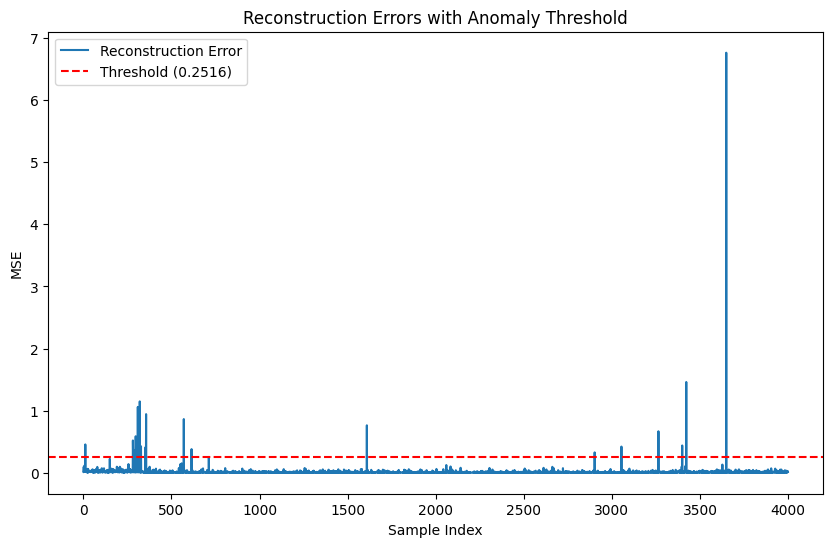


Detected 23 anomalies
Top 5 anomalies (index, user_id):
Index 11: User SDH2394
Index 281: User CAG2442
Index 282: User WSA1765
Index 294: User IKP1047
Index 295: User CAM3050

Example anomaly (Index 11, User SDH2394):
Input (first 5 features): [-0.01291102 -0.5607577  -0.30898586 -0.27228123 -0.0117177 ]
Output (first 5 features): [ 0.08226723 -0.64601094 -0.3156228  -0.3448324  -0.09245557]


In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, precision_recall_curve
import os
import matplotlib.pyplot as plt
import pickle
import time

# Model classes (unchanged)
class Encoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, latent_dim):
        super(Encoder, self).__init__()
        self.bilstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True, bidirectional=True)
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim * 2, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim)
        )

    def forward(self, x):
        lstm_out, _ = self.bilstm(x)
        latent = self.fc(torch.mean(lstm_out, dim=1))
        return latent

class Decoder(nn.Module):
    def __init__(self, latent_dim, output_dim, seq_len):
        super(Decoder, self).__init__()
        self.seq_len = seq_len
        self.output_dim = output_dim
        self.fc = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, output_dim * seq_len)
        )

    def forward(self, x):
        reconstructed = self.fc(x)
        reconstructed = reconstructed.view(-1, self.seq_len, self.output_dim)
        return reconstructed

class Autoencoder(nn.Module):
    def __init__(self, encoder, decoder):
        super(Autoencoder, self).__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, x):
        latent = self.encoder(x)
        reconstructed = self.decoder(latent)
        return reconstructed

# Preprocess new data (fixed scaler)
def preprocess_new_data(csv_files, expected_input_dim):
    try:
        dataframes = [pd.read_csv(file, index_col='Unnamed: 0') for file in csv_files]
    except FileNotFoundError as e:
        raise FileNotFoundError(f"CSV file not found: {e}")

    common_index = dataframes[0].index
    for df in dataframes[1:]:
        common_index = common_index.intersection(df.index)
    if len(common_index) == 0:
        raise ValueError("No common indices found across CSV files.")
    dataframes = [df.loc[common_index] for df in dataframes]

    data = np.stack([df.values for df in dataframes], axis=1)
    actual_input_dim = data.shape[-1]
    if actual_input_dim != expected_input_dim:
        raise ValueError(f"Input dimension mismatch: got {actual_input_dim}, expected {expected_input_dim}")
    print(f"Input dimension: {actual_input_dim}")

    data = np.nan_to_num(data, nan=0.0)

    scaler_file = "scaler.pkl"
    if os.path.exists(scaler_file):
        with open(scaler_file, "rb") as f:
            scaler = pickle.load(f)
    else:
        raise FileNotFoundError(f"Scaler file {scaler_file} not found in {os.getcwd()}")

    data_reshaped = data.reshape(-1, data.shape[-1])
    data_normalized = scaler.transform(data_reshaped).reshape(data.shape)  # Fixed: use transform
    return data_normalized, common_index

# Evaluate reconstruction errors with timing
def evaluate_autoencoder(model, data_tensor, criterion, device):
    model.eval()
    reconstruction_errors = []
    start_time = time.time()
    with torch.no_grad():
        for i in range(len(data_tensor)):
            input_data = data_tensor[i:i+1].to(device)
            output = model(input_data)
            error = criterion(output, input_data).item()
            reconstruction_errors.append(error)
    inference_time = time.time() - start_time
    return reconstruction_errors, inference_time

# Detect anomalies and compute metrics
def compute_metrics(reconstruction_errors, common_index, y_true=None, threshold=None):
    # Unsupervised metrics
    mean_error = np.mean(reconstruction_errors)
    std_error = np.std(reconstruction_errors)
    if threshold is None:
        threshold = mean_error + 2 * std_error
    anomaly_flags = [1 if error > threshold else 0 for error in reconstruction_errors]
    anomaly_rate = np.mean(anomaly_flags) * 100  # Percentage of anomalies

    metrics = {
        "mean_mse": mean_error,
        "std_mse": std_error,
        "threshold": threshold,
        "anomaly_rate": anomaly_rate
    }

    # Supervised metrics (if labels provided)
    if y_true is not None:
        precision = precision_score(y_true, anomaly_flags)
        recall = recall_score(y_true, anomaly_flags)
        f1 = f1_score(y_true, anomaly_flags)
        auc_roc = roc_auc_score(y_true, reconstruction_errors)  # Use errors for ranking
        precision_vals, recall_vals, _ = precision_recall_curve(y_true, reconstruction_errors)
        auc_pr = np.trapz(recall_vals, precision_vals)
        metrics.update({
            "precision": precision,
            "recall": recall,
            "f1_score": f1,
            "auc_roc": auc_roc,
            "auc_pr": auc_pr
        })

    # Anomalies
    anomalies = [(i, common_index[i]) for i, error in enumerate(reconstruction_errors) if error > threshold]
    return metrics, anomalies

# Plot reconstruction errors
def plot_errors(reconstruction_errors, threshold, save_path="reconstruction_errors.png"):
    plt.figure(figsize=(10, 6))
    plt.plot(reconstruction_errors, label="Reconstruction Error")
    plt.axhline(y=threshold, color='r', linestyle='--', label=f"Threshold ({threshold:.4f})")
    plt.xlabel("Sample Index")
    plt.ylabel("MSE")
    plt.title("Reconstruction Errors with Anomaly Threshold")
    plt.legend()
    plt.savefig(save_path)
    plt.show()

# Main function
def main():
    # Device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # Model path
    model_path = "britd_model.pth"
    model_size = os.path.getsize(model_path) / (1024 ** 2) if os.path.exists(model_path) else 0  # Size in MB

    # Model parameters
    input_dim = 60  # Adjust to 129 if needed
    seq_len = 4
    hidden_dim = 64
    num_layers = 3
    latent_dim = 32
    print(f"Using parameters: input_dim={input_dim}, seq_len={seq_len}")

    # Initialize model
    encoder = Encoder(input_dim, hidden_dim, num_layers, latent_dim)
    decoder = Decoder(latent_dim, input_dim, seq_len)
    autoencoder = Autoencoder(encoder, decoder).to(device)

    # Load model state
    try:
        autoencoder.load_state_dict(torch.load(model_path, map_location=device))
        print(f"Model loaded from {model_path} (Size: {model_size:.2f} MB)")
    except FileNotFoundError:
        raise FileNotFoundError(f"Model file not found at {model_path}")
    except Exception as e:
        raise RuntimeError(f"Failed to load model: {e}")

    # New data
    csv_files = [
        "gran/0_6_token_counts.csv",
        "gran/6_12_token_counts.csv",
        "gran/12_18_token_counts.csv",
        "gran/18_24_token_counts.csv"
    ]

    # Preprocess data
    data_normalized, common_index = preprocess_new_data(csv_files, input_dim)
    data_tensor = torch.tensor(data_normalized, dtype=torch.float32)

    # Loss function
    criterion = nn.MSELoss()

    # Compute reconstruction errors
    reconstruction_errors, inference_time = evaluate_autoencoder(autoencoder, data_tensor, criterion, device)

    # Compute metrics (y_true is None unless you provide labels)
    y_true = None  # Replace with ground-truth labels if available (e.g., [0, 1, 0, ...])
    metrics, anomalies = compute_metrics(reconstruction_errors, common_index, y_true)

    # Print metrics
    print("\nPerformance Metrics:")
    print(f"Mean Reconstruction Error (MSE): {metrics['mean_mse']:.6f}")
    print(f"Std of Reconstruction Errors: {metrics['std_mse']:.6f}")
    print(f"Anomaly Threshold: {metrics['threshold']:.6f}")
    print(f"Anomaly Rate: {metrics['anomaly_rate']:.2f}%")
    print(f"Inference Time: {inference_time:.2f} seconds")
    print(f"Model Size: {model_size:.2f} MB")
    if y_true is not None:
        print(f"Precision: {metrics['precision']:.3f}")
        print(f"Recall: {metrics['recall']:.3f}")
        print(f"F1-Score: {metrics['f1_score']:.3f}")
        print(f"AUC-ROC: {metrics['auc_roc']:.3f}")
        print(f"AUC-PR: {metrics['auc_pr']:.3f}")

    # Plot errors
    plot_errors(reconstruction_errors, metrics['threshold'])

    # Report anomalies
    print(f"\nDetected {len(anomalies)} anomalies")
    if anomalies:
        print("Top 5 anomalies (index, user_id):")
        for idx, user_id in anomalies[:5]:
            print(f"Index {idx}: User {user_id}")

    # Inspect a sample anomaly
    if anomalies:
        sample_idx = anomalies[0][0]
        autoencoder.eval()
        with torch.no_grad():
            input_sample = data_tensor[sample_idx:sample_idx+1].to(device)
            reconstructed = autoencoder(input_sample)
            print(f"\nExample anomaly (Index {sample_idx}, User {common_index[sample_idx]}):")
            print(f"Input (first 5 features): {input_sample[0, 0, :5].cpu().numpy()}")
            print(f"Output (first 5 features): {reconstructed[0, 0, :5].cpu().numpy()}")

if __name__ == "__main__":
    main()